In [1]:
# Import des bibliothèques nécessaires 
import pandas as pd
from pandas import to_datetime
import datetime
from datetime import date, datetime
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from collections import Counter
from time import strftime
from sklearn.neighbors import NearestNeighbors
# Import plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns
import matplotlib.pyplot as plt
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg" # to be replaced by "iframe" if working on JULIE



In [2]:
# Listage des fichiers à télécharger
FILES = [
    'uber-raw-data-apr14.csv',
    'uber-raw-data-may14.csv',
    'uber-raw-data-jun14.csv',
    'uber-raw-data-jul14.csv',
    'uber-raw-data-aug14.csv',
    'uber-raw-data-sep14.csv',
]

In [3]:
# chargement des fichiers de tous les mois avec introduction index lignes cumulés
def load_uber():
    frames = []
    for f in FILES:
        dataset = pd.read_csv(f)
        print(f'  ✓ {f} — {len(dataset):,} lignes')
        frames.append(dataset)

    if not frames:
        raise FileNotFoundError('Aucun fichier Uber trouvé dans le dossier.')
    return pd.concat(frames, ignore_index=True)

dataset = load_uber()
print(f'\nTotal : {len(dataset):,} trajets')
dataset.head()

  ✓ uber-raw-data-apr14.csv — 564,516 lignes
  ✓ uber-raw-data-may14.csv — 652,435 lignes
  ✓ uber-raw-data-jun14.csv — 663,844 lignes
  ✓ uber-raw-data-jul14.csv — 796,121 lignes
  ✓ uber-raw-data-aug14.csv — 829,275 lignes
  ✓ uber-raw-data-sep14.csv — 1,028,136 lignes

Total : 4,534,327 trajets


,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


In [4]:
dataset.info() 
dataset.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4534327 entries, 0 to 4534326
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Date/Time  object 
 1   Lat        float64
 2   Lon        float64
 3   Base       object 
dtypes: float64(2), object(2)
memory usage: 138.4+ MB


,Lat,Lon
count,4.534327e+06,4.534327e+06
mean,4.073926e+01,-7.397302e+01
std,3.994991e-02,5.726670e-02
min,3.965690e+01,-7.492900e+01
25%,4.072110e+01,-7.399650e+01
50%,4.074220e+01,-7.398340e+01
75%,4.076100e+01,-7.396530e+01
max,4.211660e+01,-7.206660e+01


In [5]:
# Conversion des dates du format objet vers le format date
nouvelle_date = pd.to_datetime(dataset['Date/Time'], format='%m/%d/%Y %H:%M:%S')
dataset.insert(loc=0, column='Nouvelle_Date', value=nouvelle_date)
dataset = dataset.drop("Date/Time", axis=1)

In [6]:
# Affichage de la période couverte et contrôle des valeurs manquantes
print('Période couverte :', dataset['Nouvelle_Date'].min(), 'au',dataset['Nouvelle_Date'].max())
print('Valeurs manquantes :')
print(dataset.isna().sum())

Période couverte : 2014-04-01 00:00:00 au 2014-09-30 22:59:00
Valeurs manquantes :
Nouvelle_Date    0
Lat              0
Lon              0
Base             0
dtype: int64


In [7]:
# info sur la base de données
dataset.info() 
dataset.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4534327 entries, 0 to 4534326
Data columns (total 4 columns):
 #   Column         Dtype         
---  ------         -----         
 0   Nouvelle_Date  datetime64[ns]
 1   Lat            float64       
 2   Lon            float64       
 3   Base           object        
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 138.4+ MB


,Nouvelle_Date,Lat,Lon
count,4534327,4.534327e+06,4.534327e+06
mean,2014-07-11 18:50:50.578151424,4.073926e+01,-7.397302e+01
min,2014-04-01 00:00:00,3.965690e+01,-7.492900e+01
25%,2014-05-28 15:18:00,4.072110e+01,-7.399650e+01
50%,2014-07-17 14:45:00,4.074220e+01,-7.398340e+01
75%,2014-08-27 21:55:00,4.076100e+01,-7.396530e+01
max,2014-09-30 22:59:00,4.211660e+01,-7.206660e+01
std,NaN,3.994991e-02,5.726670e-02


In [ ]:
# Calculs des moyennes et écarts-types des latidudes et longitudes pour filtrage
print(f'Latitude moyenne : {dataset['Lat'].mean():.4f}')
print(f'Longitude moyenne : {dataset['Lon'].mean():.4f}')
print(f'Ecart-type sur latitude : {dataset['Lat'].std():.4f}')
print(f'Ecart-type sur longitude : {dataset['Lon'].std():.4f}')

Latitude moyenne : 40.7393
Longitude moyenne : -73.9730
Ecart-type sur latitude : 0.0399
Ecart-type sur longitude : 0.0573


In [9]:
# filtrage autour des moyennes selon valeurs déterminées
selection = dict(lat=(40.5, 41), lon=(-74.3, -73.6))
mask = (dataset['Lat'].between(*selection['lat'])) & (dataset['Lon'].between(*selection['lon']))
print(f'\nPoints trop éloignés à écarter : {(~mask).sum():}')
dataset = dataset.loc[mask].reset_index(drop=True)
print(f'Dataset nettoyé : {len(dataset):,} trajets')


Points trop éloignés à écarter : 17771
Dataset nettoyé : 4,516,556 trajets


In [10]:
# Détermination du nombre de bases (quartiers) : 5
print(Counter(dataset['Base']).keys())

dict_keys(['B02512', 'B02598', 'B02617', 'B02682', 'B02764'])


In [11]:
# info sur la base de données
dataset.info() 
dataset.head()
dataset.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4516556 entries, 0 to 4516555
Data columns (total 4 columns):
 #   Column         Dtype         
---  ------         -----         
 0   Nouvelle_Date  datetime64[ns]
 1   Lat            float64       
 2   Lon            float64       
 3   Base           object        
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 137.8+ MB


,Nouvelle_Date,Lat,Lon
count,4516556,4.516556e+06,4.516556e+06
mean,2014-07-11 17:56:20.285394176,4.073898e+01,-7.397363e+01
min,2014-04-01 00:00:00,4.050390e+01,-7.430000e+01
25%,2014-05-28 14:10:00,4.072110e+01,-7.399650e+01
50%,2014-07-17 13:41:00,4.074220e+01,-7.398340e+01
75%,2014-08-27 21:37:00,4.076090e+01,-7.396550e+01
max,2014-09-30 22:59:00,4.100000e+01,-7.360000e+01
std,NaN,3.704222e-02,5.064468e-02


In [ ]:
# Nombre de lignes total
print("Nombre de lignes : {}".format(dataset.shape[0]))
print()

# Vue d'ensemble du dataset
print("Vue d'ensemble du dataset : ")
display(dataset.head())
print()

# Statistiques de base
print("Statistiques de base : ")
data_desc = dataset.describe(include='all')
display(data_desc)
print()

# Contrôle du pourcentage de valeurs manquantes
print("Pourcentage de valeurs manquantes : ")
display(100*dataset.isnull().sum()/dataset.shape[0])


Number of rows: 4516556

Dataset overview: 


,Nouvelle_Date,Lat,Lon,Base
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512



Basic statistics: 


,Nouvelle_Date,Lat,Lon,Base
count,4516556,4.516556e+06,4.516556e+06,4516556
unique,NaN,NaN,NaN,5
top,NaN,NaN,NaN,B02617
freq,NaN,NaN,NaN,1453962
mean,2014-07-11 17:56:20.285394176,4.073898e+01,-7.397363e+01,NaN
min,2014-04-01 00:00:00,4.050390e+01,-7.430000e+01,NaN
25%,2014-05-28 14:10:00,4.072110e+01,-7.399650e+01,NaN
50%,2014-07-17 13:41:00,4.074220e+01,-7.398340e+01,NaN
75%,2014-08-27 21:37:00,4.076090e+01,-7.396550e+01,NaN
max,2014-09-30 22:59:00,4.100000e+01,-7.360000e+01,NaN



Percentage of missing values: 


Nouvelle_Date    0.0
Lat              0.0
Lon              0.0
Base             0.0
dtype: float64

In [13]:
# Ventilation de la colonne "Nouvelle_Date" en séparant les éléments
dataset['weekday'] = dataset['Nouvelle_Date'].dt.dayofweek
dataset['hour'] = dataset['Nouvelle_Date'].dt.hour
dataset['month'] = dataset['Nouvelle_Date'].dt.month
dataset['day'] = dataset['Nouvelle_Date'].dt.day
dataset['hour_sin'] = np.sin(2 * np.pi * dataset['hour'] / 24)
dataset['hour_cos'] = np.cos(2 * np.pi * dataset['hour'] / 24)

In [14]:
# Traduction des jours de la semaine en français
NOMS_JOURS = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
dataset['jour'] = dataset['weekday'].map(dict(enumerate(NOMS_JOURS)))
dataset.head()

,Nouvelle_Date,Lat,Lon,Base,weekday,hour,month,day,hour_sin,hour_cos,jour
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,1,0,4,1,0.0,1.0,Mardi
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,1,0,4,1,0.0,1.0,Mardi
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,1,0,4,1,0.0,1.0,Mardi
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,1,0,4,1,0.0,1.0,Mardi
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,1,0,4,1,0.0,1.0,Mardi


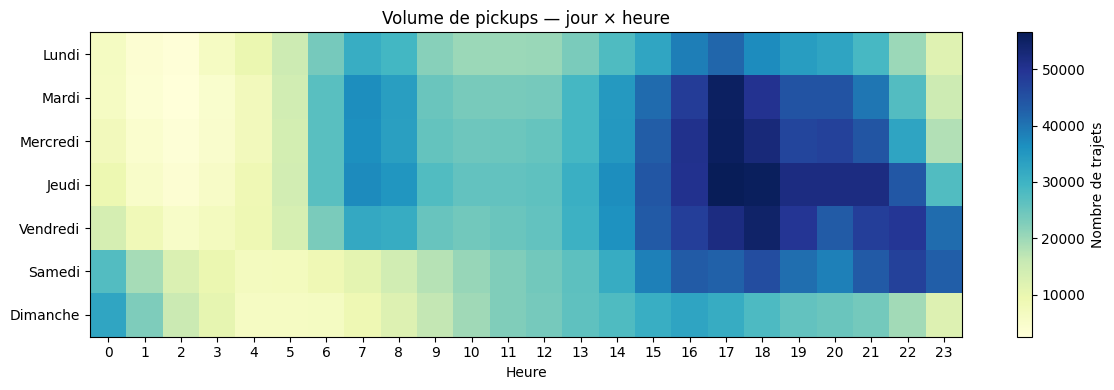

In [ ]:
# transformation du dataset pour ventiler par jour de la semaine et horaire
pivot = dataset.pivot_table(index='jour', columns='hour', values='Nouvelle_Date',
                        aggfunc='count').reindex(NOMS_JOURS)

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlGnBu')
ax.set_xticks(range(24)); ax.set_xticklabels(range(24))
ax.set_yticks(range(7));  ax.set_yticklabels(NOMS_JOURS)
ax.set_xlabel('Heure'); ax.set_title('Volume de pickups — jour × heure')
plt.colorbar(im, ax=ax, label='Nombre de trajets')
plt.tight_layout(); plt.show()

In [16]:
# --- C1 : Pipeline de pré-traitement ---

# Sous-échantillonnage stratifié par jour de semaine
# Pourquoi : DBSCAN est en O(n²) sans index spatial → 4,5 M pts = trop lent
# On garde 50 000 pts répartis uniformément (≈7 142 par jour)
N_SAMPLE = 50_000
sample = (dataset.groupby('weekday', group_keys=False)
            .apply(lambda g: g.sample(min(len(g), N_SAMPLE // 7), random_state=42))
            .reset_index(drop=True))
print(f'Échantillon : {len(sample):,} points — répartition jour:')
print(sample['jour'].value_counts().reindex(NOMS_JOURS))

# StandardScaler sur [Lat, Lon] : impératif pour que DBSCAN (distance euclidienne)
# traite latitude et longitude de manière isotrope (écarts-types ≠ à l'origine)
X = sample[['Lat', 'Lon']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('\nMoyennes (Lat, Lon) :', scaler.mean_)
print('Écarts-types       :', scaler.scale_)

Échantillon : 49,994 points — répartition jour:
jour
Lundi       7142
Mardi       7142
Mercredi    7142
Jeudi       7142
Vendredi    7142
Samedi      7142
Dimanche    7142
Name: count, dtype: int64

Moyennes (Lat, Lon) : [ 40.73888995 -73.97313875]
Écarts-types       : [0.03754021 0.05084432]


C:\Users\patri\AppData\Local\Temp\ipykernel_28284\766002491.py:8: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [ ]:
# Utilisation des méthodes du coude pour trouver le nombre optimal de clusters

inertias =  []
silhouette = []
for i in range (2,11):
    kmeans = KMeans(n_clusters= i, random_state = 42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels, sample_size=10_000, random_state=42))
    print(f' i={i} inertie={kmeans.inertia_:10.0f} silhouette={silhouette[-1]:.3f}')

 i=2 inertie=     67305 silhouette=0.656
 i=3 inertie=     43276 silhouette=0.410
 i=4 inertie=     33725 silhouette=0.419
 i=5 inertie=     26346 silhouette=0.434
 i=6 inertie=     20733 silhouette=0.453
 i=7 inertie=     16881 silhouette=0.469
 i=8 inertie=     14483 silhouette=0.416
 i=9 inertie=     12447 silhouette=0.439
 i=10 inertie=     11189 silhouette=0.399


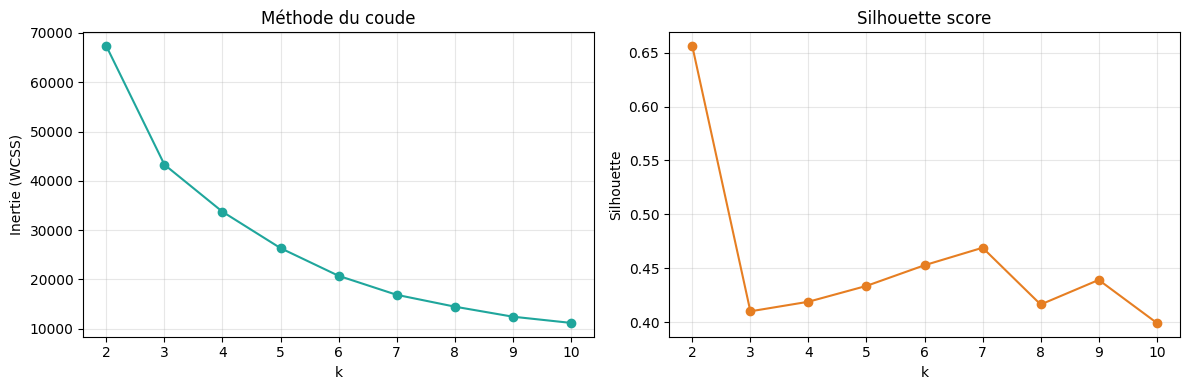


→ k optimal (silhouette) : 2


In [18]:
# Visualisation : coude de l'inertie + silhouette score
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(range (2,11)), inertias, 'o-', color='#1FA69C'); axes[0].set_title('Méthode du coude')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertie (WCSS)'); axes[0].grid(alpha=.3)
axes[1].plot(list(range (2,11)), silhouette, 'o-', color='#E67E22'); axes[1].set_title('Silhouette score')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette'); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

# NOTE analytique : la silhouette maximale est à k=2 (0.656)
# mais c'est un résultat dégénéré (Manhattan vs aéroports).
# Le coude de l'inertie montre un palier vers k=6-7.
K_OPTIM = int(list(range (2,11))[int(np.argmax(silhouette))])
print(f'\n→ k optimal (silhouette) : {K_OPTIM}')

In [19]:
# --- KMeans k=2 : résultat "optimal" par silhouette mais dégénéré ---
km2 = KMeans(n_clusters=2, random_state=42, n_init=10)
sample['cluster_km2'] = km2.fit_predict(X_scaled)
sil_km2 = silhouette_score(X_scaled, sample['cluster_km2'], sample_size=10_000, random_state=42)

centroids_2 = scaler.inverse_transform(km2.cluster_centers_)
c2_dataset = pd.DataFrame(centroids_2, columns=['Lat', 'Lon'])
c2_dataset['count'] = sample['cluster_km2'].value_counts().sort_index().values
print(f'KMeans k=2 — silhouette = {sil_km2:.3f}')
print(c2_dataset)
print(f'\n⚠ Résultat dégénéré : {c2_dataset["count"].iloc[0]:,} pts vs {c2_dataset["count"].iloc[1]:,} pts')
print('  → Sépare Manhattan/Brooklyn des aéroports, pas exploitable pour le routage chauffeur.')

KMeans k=2 — silhouette = 0.656
         Lat        Lon  count
0  40.740932 -73.984189  46429
1  40.712291 -73.829222   3565

⚠ Résultat dégénéré : 46,429 pts vs 3,565 pts
  → Sépare Manhattan/Brooklyn des aéroports, pas exploitable pour le routage chauffeur.


In [20]:
# --- KMeans k=6 : compromis métier retenu ---
K_METIER = 6
km = KMeans(n_clusters=K_METIER, random_state=42, n_init=10)
sample['cluster_km'] = km.fit_predict(X_scaled)
sil_km6 = silhouette_score(X_scaled, sample['cluster_km'], sample_size=10_000, random_state=42)

# Centroïdes en coordonnées réelles (inverse_transform)
centroids_real = scaler.inverse_transform(km.cluster_centers_)
centroids_dataset = pd.DataFrame(centroids_real, columns=['Lat', 'Lon'])
centroids_dataset['count'] = sample['cluster_km'].value_counts().sort_index().values
centroids_dataset['cluster'] = centroids_dataset.index

print(f'KMeans k={K_METIER} — silhouette = {sil_km6:.3f}')
print(centroids_dataset.sort_values('count', ascending=False).to_string(index=False))
print(f'\n✓ 6 zones géographiques distinctes — exploitable pour la répartition de flotte.')

KMeans k=6 — silhouette = 0.453
      Lat        Lon  count  cluster
40.729085 -73.995438  21234        1
40.764542 -73.974464  18896        4
40.679585 -73.966309   4985        3
40.797181 -73.888247   2813        0
40.659370 -73.783331   1645        2
40.701428 -74.180378    421        5

✓ 6 zones géographiques distinctes — exploitable pour la répartition de flotte.


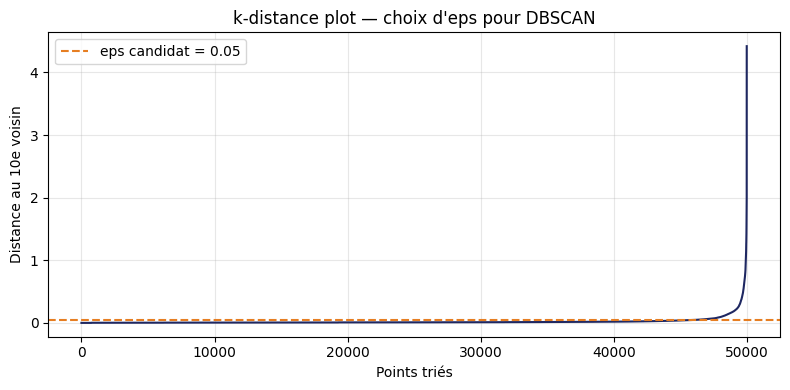

In [21]:
# --- C3 : Choix d'eps pour DBSCAN via k-distance plot ---
# Le k-distance plot trie les distances au k-ème voisin le plus proche.
# Le "coude" de cette courbe donne une valeur d'eps pertinente :
#   au-dessous → trop de bruit, au-dessus → un seul cluster.
MIN_SAMPLES = 10  # Paramètre de densité minimale (nombre de voisins)
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
kdist = np.sort(distances[:, -1])  # Distance au 10e voisin, triée

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(kdist, color='#1E2761')
ax.set_xlabel('Points triés')
ax.set_ylabel(f'Distance au {MIN_SAMPLES}e voisin')
ax.set_title('k-distance plot — choix d\'eps pour DBSCAN')
ax.axhline(0.05, color='#E67E22', linestyle='--', label='eps candidat = 0.05')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [22]:
# --- C3 : Application de DBSCAN avec les paramètres retenus ---
EPS = 0.05          # Rayon de voisinage (en unités StandardScaler)
db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
sample['cluster_db'] = db.fit_predict(X_scaled)

# Comptage propre des clusters (exclure -1 = bruit)
labels_uniques = set(sample['cluster_db'].unique())
n_clusters_db  = len(labels_uniques - {-1})
n_noise        = int((sample['cluster_db'] == -1).sum())
print(f'Clusters DBSCAN : {n_clusters_db}')
print(f'Points de bruit : {n_noise:,} ({n_noise/len(sample):.1%})')

Clusters DBSCAN : 61
Points de bruit : 2,802 (5.6%)


In [23]:
# --- C4 : Comparaison chiffrée KMeans k=2, k=6 et DBSCAN ---

# Silhouette KMeans k=6 (le modèle retenu pour la vue stratégique)
sil_km = silhouette_score(X_scaled, sample['cluster_km'], sample_size=10_000, random_state=42)

# Silhouette DBSCAN (on exclut le bruit : label -1)
mask_db = sample['cluster_db'] != -1
sil_db = silhouette_score(X_scaled[mask_db], sample.loc[mask_db, 'cluster_db'],
                          sample_size=min(10_000, mask_db.sum()), random_state=42) if mask_db.sum() > 100 else np.nan

# Tableau de synthèse avec les 3 configurations testées
comparaison = pd.DataFrame({
    'Critère'            : ['Silhouette score', 'Nb clusters', '% bruit',
                             'Forme', 'Reproductibilité', 'Temps (50 k)'],
    'KMeans (k=2)'       : [f'{sil_km2:.3f}', 2, '0 %',
                              'Sphérique', 'random_state=42', '< 1 s'],
    f'KMeans (k={K_METIER})': [f'{sil_km:.3f}', K_METIER, '0 %',
                              'Sphérique', 'random_state=42', '< 1 s'],
    f'DBSCAN (eps={EPS})'  : [f'{sil_db:.3f}' if not np.isnan(sil_db) else 'N/A',
                              n_clusters_db, f'{n_noise/len(sample):.1%}',
                              'Arbitraire', 'Déterministe', '≈ 3 s'],
})
print('Comparaison des 3 configurations :')
comparaison

Comparaison des 3 configurations :


,Critère,KMeans (k=2),KMeans (k=6),DBSCAN (eps=0.05)
0,Silhouette score,0.656,0.453,-0.047
1,Nb clusters,2,6,61
2,% bruit,0 %,0 %,5.6%
3,Forme,Sphérique,Sphérique,Arbitraire
4,Reproductibilité,random_state=42,random_state=42,Déterministe
5,Temps (50 k),< 1 s,< 1 s,≈ 3 s


C:\Users\patri\AppData\Local\Temp\ipykernel_28284\629474814.py:1: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



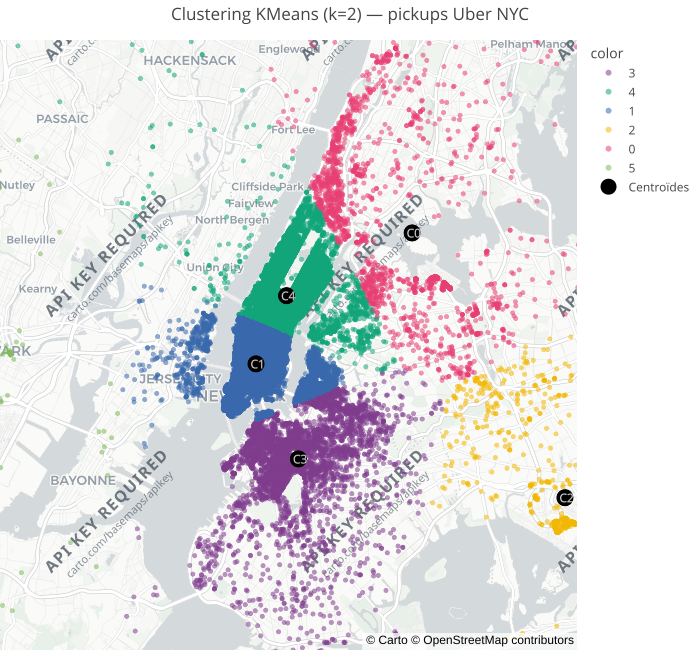

In [ ]:
fig = px.scatter_mapbox(
    sample, lat='Lat', lon='Lon', color=sample['cluster_km'].astype(str),
    hover_data={'jour': True, 'hour': True, 'cluster_km': True},
    zoom=10, height=650, opacity=0.55,
    title=f'Clustering KMeans (k={K_OPTIM}) — pickups Uber NYC',
    color_discrete_sequence=px.colors.qualitative.Bold,
)
# Superposition des centroïdes
fig.add_scattermapbox(
    lat=centroids_dataset['Lat'], lon=centroids_dataset['Lon'],
    mode='markers+text',
    marker=dict(size=18, color='black'),
    text=[f'★ C{i}' for i in centroids_dataset['cluster']],
    textfont=dict(color='white', size=12),
    name='Centroïdes',
)
fig.update_layout(mapbox_style='carto-positron', margin=dict(l=0, r=0, t=40, b=0))
fig.write_html('hotspots_kmeans.html')
fig.show()

C:\Users\patri\AppData\Local\Temp\ipykernel_28284\2056759884.py:4: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



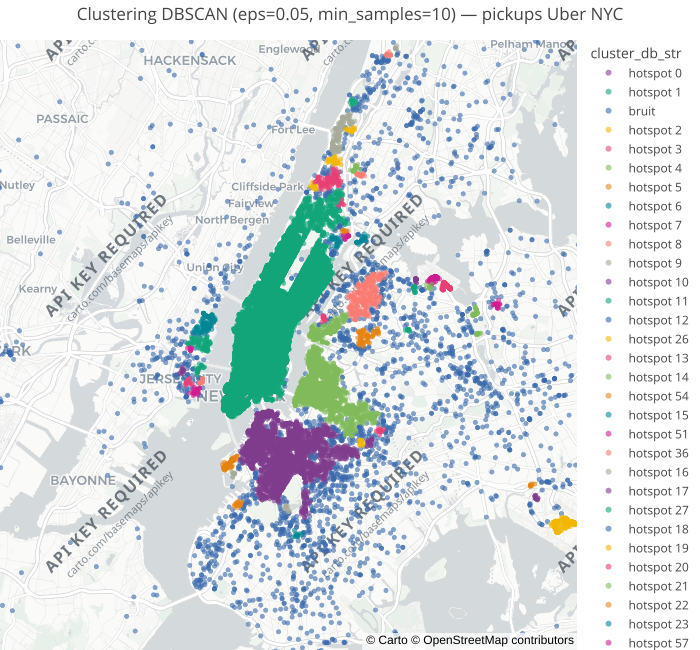

In [25]:
# Visualisation DBSCAN : les points de bruit (-1) sont étiquetés "bruit"
plot_db = sample.copy()
plot_db['cluster_db_str'] = plot_db['cluster_db'].map(lambda x: 'bruit' if x == -1 else f'hotspot {x}')
fig = px.scatter_mapbox(
    plot_db, lat='Lat', lon='Lon', color='cluster_db_str',
    hover_data={'jour': True, 'hour': True},
    zoom=10, height=650, opacity=0.6,
    title=f'Clustering DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES}) — pickups Uber NYC',
    color_discrete_sequence=px.colors.qualitative.Bold,
)
fig.update_layout(mapbox_style='carto-positron', margin=dict(l=0, r=0, t=40, b=0))
fig.write_html('hotspots_dbscan.html')  # Livrable HTML exporté
fig.show()

In [26]:
def hotspots_slot(dataset_slot, k=5):
    if len(dataset_slot) < 50:
        return pd.DataFrame()
    X = dataset_slot[['Lat','Lon']].values
    Xs = StandardScaler().fit_transform(X)
    km = KMeans(n_clusters=k, random_state=42, n_init=5)
    km.fit(Xs)
    # Centroïdes en coordonnées réelles : moyenne des points de chaque cluster
    centers = np.array([X[km.labels_ == i].mean(axis=0) for i in range(k)])
    counts  = np.array([(km.labels_ == i).sum() for i in range(k)])
    return pd.DataFrame({
        'Lat': centers[:,0], 'Lon': centers[:,1],
        'count': counts,
    })

# Exemple : vendredi 18h
ex = dataset[(dataset['weekday'] == 4) & (dataset['hour'] == 18)]
print(f'Vendredi 18h — {len(ex):,} trajets')
hs = hotspots_slot(ex, k=6)
hs.sort_values('count', ascending=False)

Vendredi 18h — 54,566 trajets


,Lat,Lon,count
1,40.762647,-73.974823,23491
5,40.729453,-73.997349,22649
0,40.685351,-73.968161,4963
2,40.792396,-73.882408,2080
3,40.663105,-73.779821,1004
4,40.704759,-74.179866,379


C:\Users\patri\AppData\Local\Temp\ipykernel_28284\493646576.py:2: DeprecationWarning:

*density_mapbox* is deprecated! Use *density_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



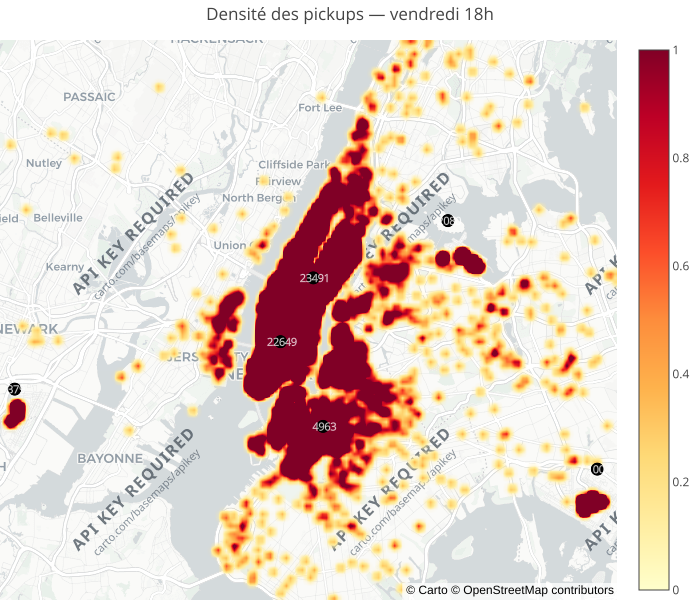

In [27]:
# Carte hotspots pour un créneau donné
fig = px.density_mapbox(
    ex.sample(min(20_000, len(ex)), random_state=42),
    lat='Lat', lon='Lon', radius=8,
    zoom=10, height=600,
    title='Densité des pickups — vendredi 18h',
    color_continuous_scale='YlOrRd',
)
fig.add_scattermapbox(
    lat=hs['Lat'], lon=hs['Lon'], mode='markers+text',
    marker=dict(size=14, color='black'),
    text=[f'★ {int(c)}' for c in hs['count']],
    textfont=dict(color='white', size=11),
    name='Hotspots',
)
fig.update_layout(mapbox_style='carto-positron', margin=dict(l=0, r=0, t=40, b=0))
fig.write_html('hotspots_vendredi_18h.html')
fig.show()

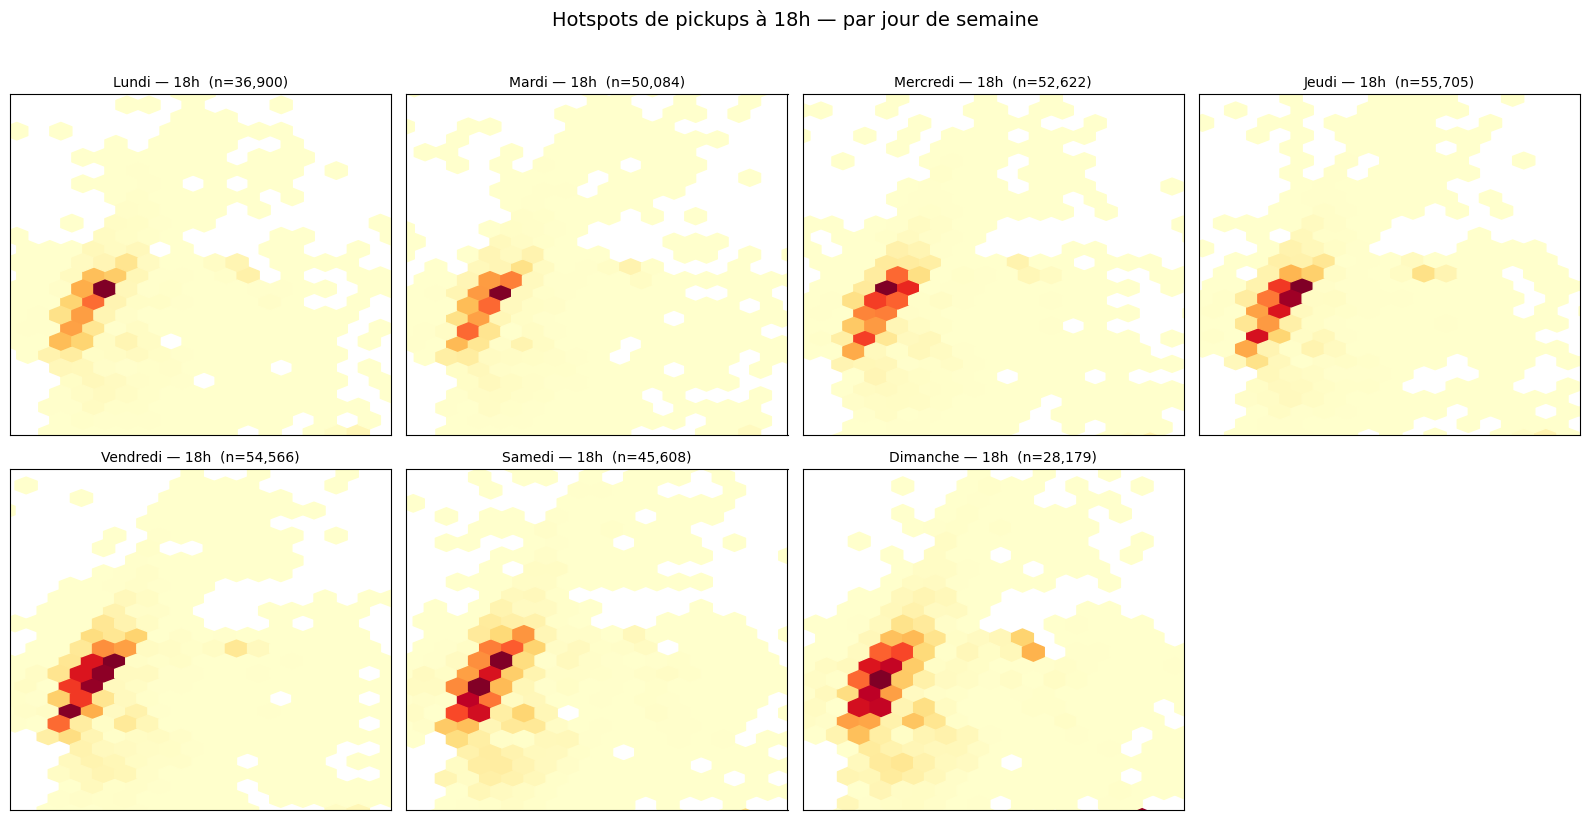

In [28]:
# Grille 7 jours × hexbin : visualisation rapide de la variation spatiale
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, jour in enumerate(NOMS_JOURS):
    sub = dataset[(dataset['weekday'] == i) & (dataset['hour'] == 18)]
    ax = axes[i]
    if len(sub) > 50:
        ax.hexbin(sub['Lon'], sub['Lat'], gridsize=40, cmap='YlOrRd', mincnt=1)
    ax.set_title(f'{jour} — 18h  (n={len(sub):,})', fontsize=10)
    ax.set_xlim(-74.05, -73.75); ax.set_ylim(40.65, 40.90)
    ax.set_xticks([]); ax.set_yticks([])
axes[-1].axis('off')  # 8e case vide (7 jours, grille 2×4)
plt.suptitle('Hotspots de pickups à 18h — par jour de semaine', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

In [ ]:
# CONCLUSIONS

In [ ]:
# Interprétation :
# KMeans fournit une partition géographique exhaustive utile pour la répartition uniforme de la flotte
# DBSCAN identifie les vraies zones denses de pickups et isole les zones périphériques comme bruit 
# (plus proche de la réalité opérationnelle)
# La densité des pickups varie fortement selon les jours et les heures : 
# ce qu'un chauffeur doit voir à 18h00 un vendredi dans les quartiers de Midtown, Williamsburg ou Downtown
# n'est pas identique à ce qu'il doit voir un lundi dans les quartiers des aéroports JFK ou La Guardia

In [ ]:
# Recommandation : combiner les deux : 
# KMeans pour la vue stratégique 24h
# DBSCAN pour la vue tactique en temps réel  (avec mise à jour toutes les 15 minutes sur fenêtre glissante)

In [ ]:
# Perspectives envisageables :
# Métrique haversine plutôt qu'euclidienne standardisée (DBSCAN avec metric='haversine' sur radians)
# HDBSCAN pour éviter le réglage manuel d'EPS
# Dashboard Plotly Dash / Streamlit temps réel pour l'application chauffeur
# A/B test : mesurer la réduction effective du temps d'attente suite au déploiement